# 01 | Data Cleaning
**Project:** Predictive Analytics and AI-Driven Nutrition Solution for Early Detection and Management of Type 2 Diabetes

**Notebook:** 1 of 6

**Purpose:** This notebook focuses on loading the raw dataset and carrying out an initial exploration to understand its structure, quality, and key characteristics.

It also covers the main data cleaning steps, including:
- Removing duplicate records
- Handling missing values through imputation
- Detecting and capping outliers.

**Output:** `data/processed/glucose_spike_cleaned.csv` 
This cleaned dataset will be used for the exploratory data analysis stage.


**Next notebook:** `02_eda.ipynb`

---

## 0. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams["figure.dpi"]   = 120
plt.rcParams["savefig.bbox"] = "tight"

SPIKE_COLORS = {0: "#4CAF50", 1: "#E53935"}
ACCENT       = "#2196F3"
RANDOM_STATE = 42

print("Libraries loaded.")

Libraries loaded.


---
## 1. Load Dataset

In [2]:
# update this path to where your raw CSV lives
DATA_PATH = r"C:\Users\ifech\OneDrive\Desktop\glucose-spike-prediction\data\raw\Glucose_Spike_Dataset - Sheet1.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

Dataset loaded: 5,150 rows, 28 columns


---
## 2. Initial Data Exploration
Understand the dataset's structure, quality, and statistical properties before any transformation.

## 2.1 Check First 5 Rows

In [3]:
# always good to eyeball the data first. check column names, types, and obvious issues
df.head()

,patient_id,age,gender,bmi,diabetes_type,meal_time,carb_intake,protein_intake,fat_intake,fiber_intake,...,sleep_hours,smoking_status,alcohol_consumption,pre_meal_glucose,post_meal_glucose,glucose_change,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike
0,1127,63,Male,25.318753,Type 2,Snack,206.078625,96.988928,81.332092,19.881550,...,6.038772,Yes,No,80.511484,185.125157,104.613673,139.121175,10.313445,2.057729,1
1,861,43,Female,29.887205,Type 1,Snack,110.277131,41.988332,65.323781,9.660801,...,7.787871,No,No,102.325117,101.612905,-0.712212,80.057182,11.297959,2.153776,0
2,1131,65,Female,21.831540,Type 1,Breakfast,88.692079,74.612428,26.828247,26.701083,...,9.146882,No,No,99.639334,123.456632,23.817298,46.809459,3.309272,1.309858,0
3,1096,56,Male,26.610861,Type 2,Dinner,168.193534,70.944312,58.451133,23.006694,...,5.856119,No,No,116.822669,122.497946,5.675277,127.919532,7.278996,2.061997,0
4,1045,58,Male,26.649132,Type 2,Dinner,93.580856,74.851625,14.576802,19.789018,...,7.327162,Yes,No,99.878155,98.419762,-1.458393,58.098774,4.705152,1.168034,0


## 2.2 Check Last 5 Rows

In [4]:
# tail() helps catch any junk rows or shifted values at the end of the file
df.tail()

,patient_id,age,gender,bmi,diabetes_type,meal_time,carb_intake,protein_intake,fat_intake,fiber_intake,...,sleep_hours,smoking_status,alcohol_consumption,pre_meal_glucose,post_meal_glucose,glucose_change,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike
5145,128,52,Male,17.089172,Type 1,Snack,113.399998,63.730627,84.595744,14.292383,...,5.442210,Yes,No,83.287935,107.931203,24.643268,49.173275,7.879168,1.328944,0
5146,143,73,Male,27.745089,Type 2,Snack,195.660539,109.858407,27.575196,18.824318,...,4.311916,No,No,118.782185,160.973903,42.191718,105.310937,10.339106,2.329110,1
5147,803,65,Male,18.788603,Type 2,Dinner,48.522283,56.986410,19.381166,16.691101,...,7.171125,Yes,No,113.424925,143.757116,30.332191,42.726837,2.889762,1.690263,0
5148,246,79,Male,26.539871,Type 2,Snack,102.805482,60.987416,44.298409,21.329768,...,7.713246,No,Yes,92.099547,134.721431,42.621884,44.847135,4.797321,1.354043,1
5149,331,35,Female,24.051558,Type 2,Breakfast,186.755906,78.396761,49.267450,34.102746,...,5.034909,Yes,No,100.561873,161.330950,60.769077,100.459622,5.460261,1.451803,1


## 2.3 Check Data Shape, Duplicates and Memory Used

In [5]:
print(f"{chr(8212)*50}")
print(f"  Dataset Shape   : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"  Duplicate Rows  : {df.duplicated().sum()}")
print(f"  Memory Usage    : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"{chr(8212)*50}")

——————————————————————————————————————————————————
  Dataset Shape   : 5,150 rows x 28 columns
  Duplicate Rows  : 150
  Memory Usage    : 1236.1 KB
——————————————————————————————————————————————————


## 2.4 Check Data Types & Column Information

In [6]:
# info() gives a quick summary of column names, non-null counts, and dtypes all at once
print("Data Info:")
df.info()

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            5150 non-null   int64  
 1   age                   5150 non-null   int64  
 2   gender                5150 non-null   str    
 3   bmi                   5150 non-null   float64
 4   diabetes_type         5150 non-null   str    
 5   meal_time             5150 non-null   str    
 6   carb_intake           5150 non-null   float64
 7   protein_intake        5150 non-null   float64
 8   fat_intake            5150 non-null   float64
 9   fiber_intake          4841 non-null   float64
 10  sugar_intake          5150 non-null   float64
 11  glycemic_index        5150 non-null   float64
 12  portion_size          5150 non-null   float64
 13  water_intake          5150 non-null   float64
 14  insulin_dose          4839 non-null   float64
 15  medication_adherence 

## 2.5 Check Missing Values

In [7]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({"Count": missing, "Percent (%)": missing_pct})

# only show columns that actually have missing values
missing_df = missing_df[missing_df["Count"] > 0]
print("Missing Values:")
print(missing_df.to_string())

Missing Values:
              Count  Percent (%)
fiber_intake    309         6.00
insulin_dose    311         6.04
stress_level    315         6.12
sleep_hours     308         5.98


## 2.6 Summary Statistics of Numerical Variables

In [8]:
# describe() gives count, mean, std, min, quartiles, and max for every numeric column
print("Numerical Summary Statistics:")
df.describe().round(2)

Numerical Summary Statistics:


,patient_id,age,bmi,carb_intake,protein_intake,fat_intake,fiber_intake,sugar_intake,glycemic_index,portion_size,...,physical_activity,stress_level,sleep_hours,pre_meal_glucose,post_meal_glucose,glucose_change,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike
count,5150.00,5150.00,5150.00,5150.00,5150.00,5150.00,4841.00,5150.00,5150.00,5150.00,...,5150.00,4835.00,4842.00,5150.00,5150.00,5150.00,5150.00,5150.00,5150.00,5150.00
mean,607.98,48.34,27.04,122.52,59.87,49.81,18.10,46.04,60.04,399.11,...,45.36,5.48,6.51,110.74,144.72,33.98,73.60,9.75,1.80,0.47
std,345.24,17.86,4.98,58.02,24.52,19.60,7.92,24.14,14.67,120.33,...,24.24,2.87,1.46,13.54,32.43,29.21,40.32,12.27,0.74,0.50
min,1.00,18.00,16.00,10.00,5.00,5.00,2.00,0.00,30.00,100.00,...,0.00,1.00,3.00,70.00,70.00,-57.05,3.00,0.27,0.39,0.00
25%,312.25,33.00,23.63,81.48,43.32,36.36,12.67,29.08,49.81,319.42,...,28.35,3.00,5.49,102.02,122.05,12.88,43.83,4.15,1.38,0.00
50%,616.00,48.00,26.99,121.87,59.17,49.69,17.98,45.74,59.86,399.31,...,44.87,5.00,6.51,111.00,143.08,32.33,69.55,6.76,1.70,0.00
75%,906.75,64.00,30.43,163.94,76.33,62.70,23.46,62.03,70.49,478.16,...,61.82,8.00,7.50,119.94,165.60,52.27,98.53,10.43,2.04,1.00
max,1200.00,79.00,44.09,319.61,148.56,131.99,48.21,131.88,100.00,807.29,...,141.50,10.00,10.00,152.89,273.80,161.23,271.34,152.19,9.66,1.00


## 2.7 Summary Statistics of Categorical Variables

In [9]:
# passing include="object" gives us count, unique values, mode (top), and its frequency
print("Categorical Summary Statistics:")
df.describe(include="object")

Categorical Summary Statistics:


,gender,diabetes_type,meal_time,smoking_status,alcohol_consumption
count,5150,5150,5150,5150,5150
unique,2,2,4,2,2
top,Female,Type 2,Dinner,No,No
freq,2695,4397,1331,4125,3832


## 2.8 Outlier Detection

In [10]:
# using the IQR method, any value more than 1.5xIQR below Q1 or above Q3 is flagged
numeric_cols = df.select_dtypes(include=np.number).drop(columns=["patient_id"])

outlier_summary = []
for col in numeric_cols.columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "Column"       : col,
        "Lower Fence"  : round(lower, 2),
        "Upper Fence"  : round(upper, 2),
        "Outlier Count": n_out,
        "Outlier %"    : round(n_out / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("Outlier Count", ascending=False)
print(outlier_df[outlier_df["Outlier Count"] > 0].to_string(index=False))

              Column  Lower Fence  Upper Fence  Outlier Count  Outlier %
medication_adherence         1.00         1.00            978      18.99
    carb_fiber_ratio        -5.26        19.84            410       7.96
        insulin_dose        -0.97         7.16            366       7.11
     meal_risk_score         0.39         3.03            219       4.25
       glycemic_load       -38.21       180.57             57       1.11
      glucose_change       -46.19       111.34             47       0.91
    pre_meal_glucose        75.15       146.82             46       0.89
   post_meal_glucose        56.71       230.94             35       0.68
        portion_size        81.30       716.28             24       0.47
        water_intake       -76.42       571.11             24       0.47
        sugar_intake       -20.33       111.44             22       0.43
   physical_activity       -21.86       112.03             22       0.43
          fat_intake        -3.16       102.21     

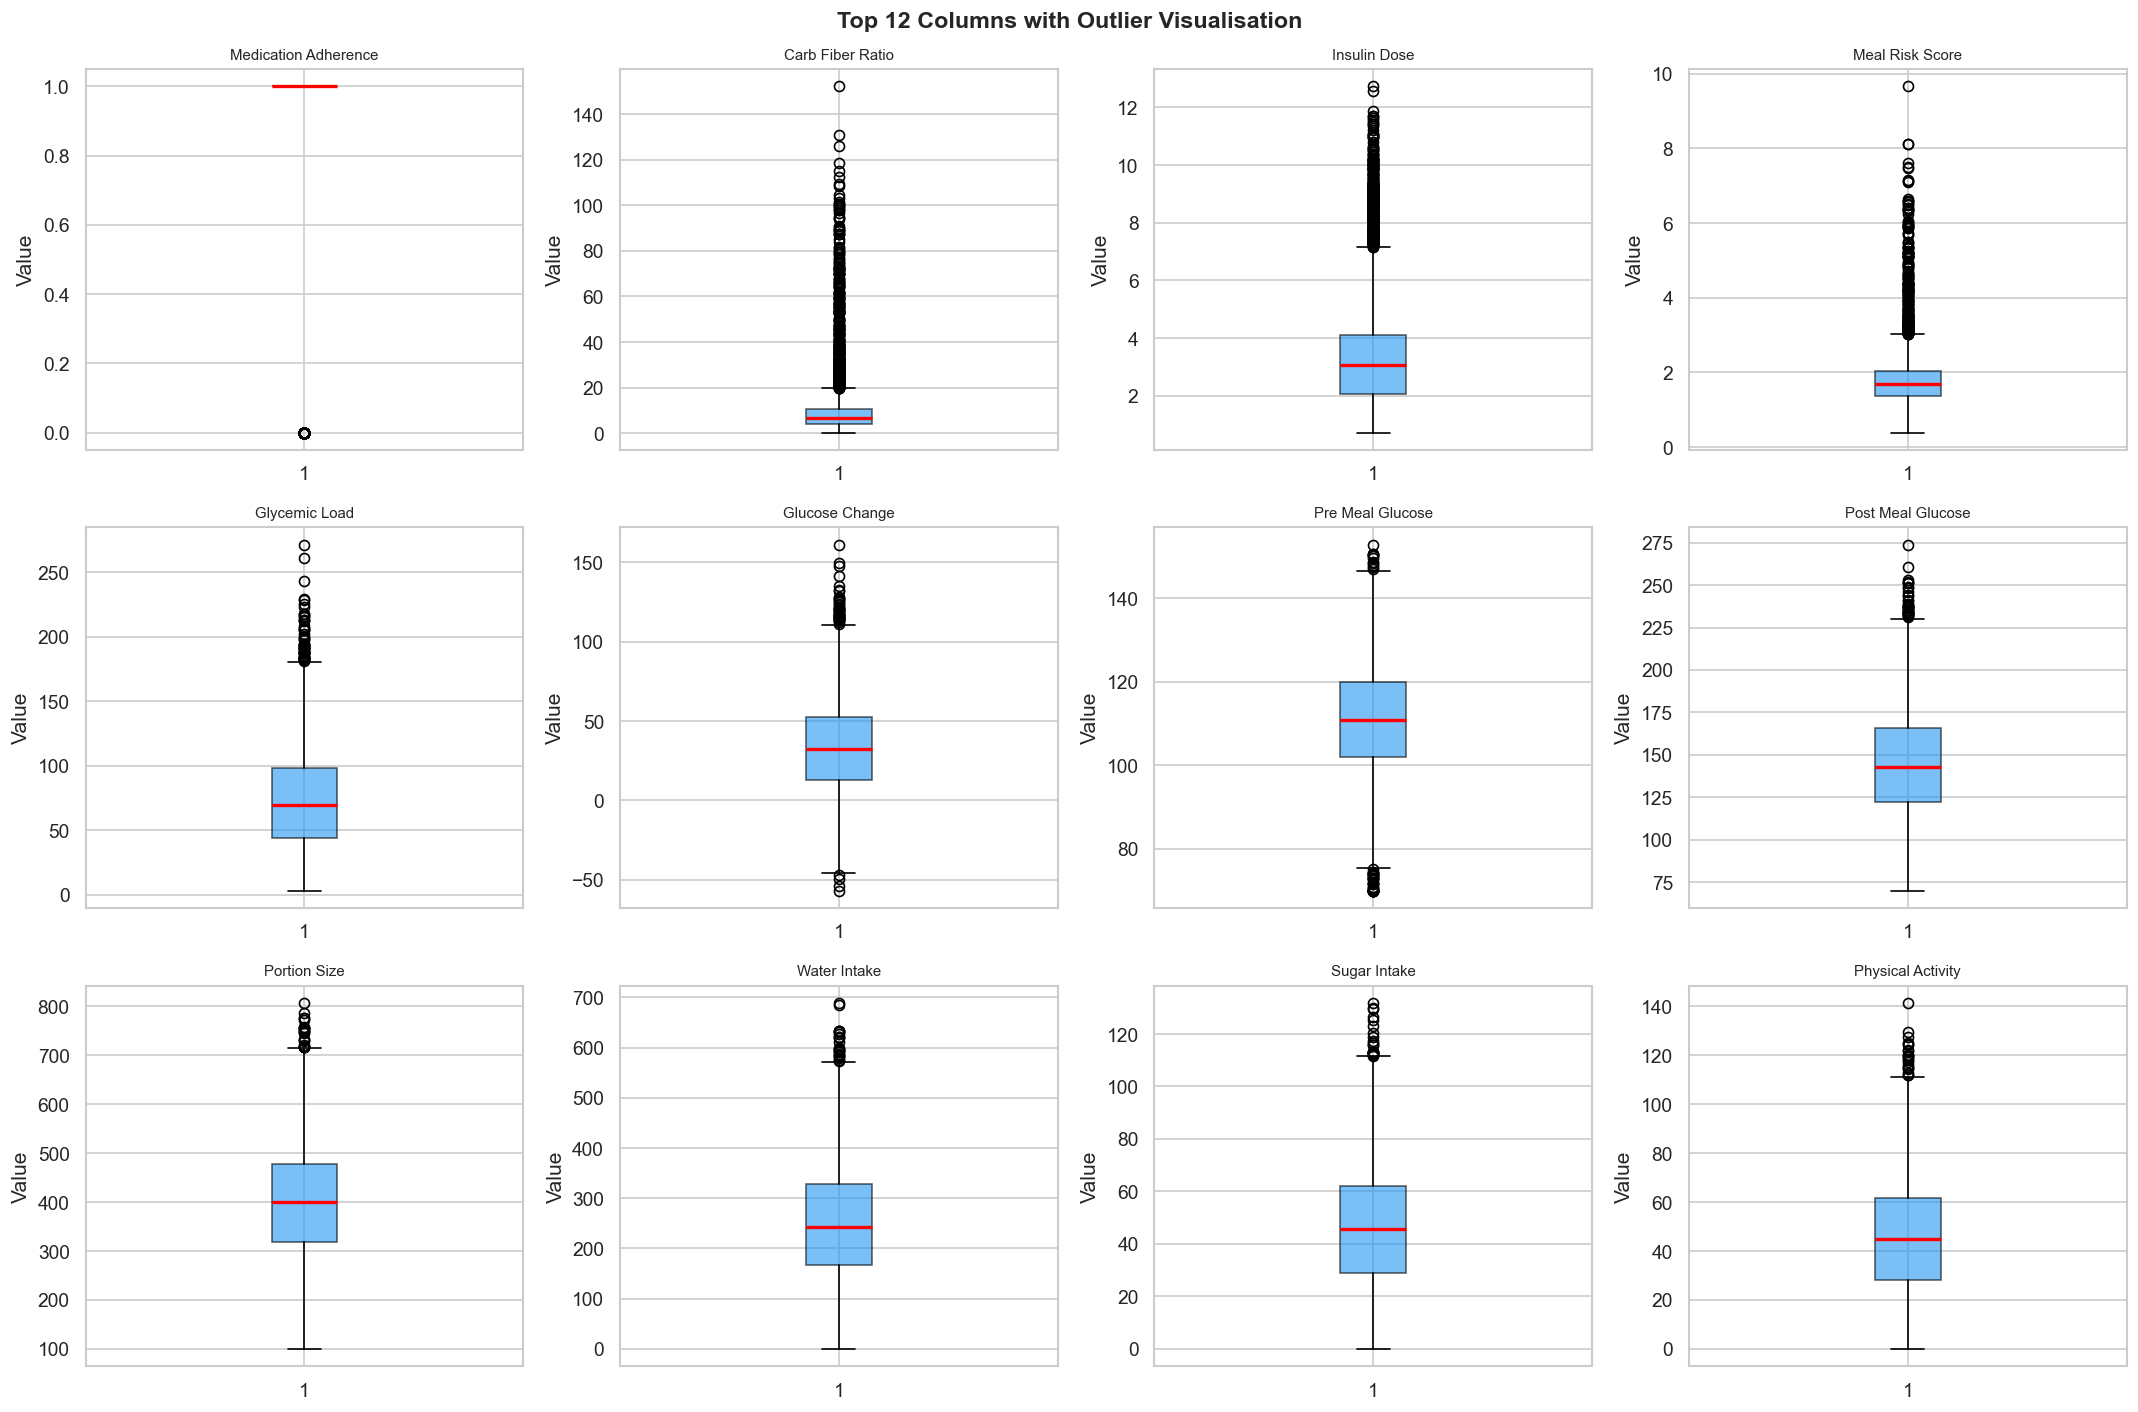

In [11]:
# box plots make it easy to see how spread out the outliers are for each column
top_outlier_cols = (outlier_df[outlier_df["Outlier Count"] > 0]
                    .head(12)["Column"].tolist())

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("Top 12 Columns with Outlier Visualisation", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flat, top_outlier_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=ACCENT, alpha=0.6),
               medianprops=dict(color="red", linewidth=2))
    ax.set_title(col.replace("_", " ").title(), fontsize=9)
    ax.set_ylabel("Value")

for ax in axes.flat[len(top_outlier_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

---
# 3. Data Cleaning
Here, we will address duplicates, missing values, and outliers identified in Step 2.

## 3.1 Remove Duplicate Rows

In [12]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)

print(f"Duplicates removed : {before - len(df)}")
print(f"Rows remaining     : {len(df):,}")

Duplicates removed : 150
Rows remaining     : 5,000


## 3.2 Fill Missing Values
Here we will replace missing values with the Median score

In [13]:
# median is safer than mean here because some of these columns have skewed distributions
# mean would pull towards the outliers whereas median stays at the centre
cols_with_missing = ["fiber_intake", "insulin_dose", "stress_level", "sleep_hours"]

for col in cols_with_missing:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  {col:<20} - filled nulls with median = {median_val:.2f}")

print(f"\nMissing values remaining: {df.isnull().sum().sum()}")

  fiber_intake         - filled nulls with median = 17.98
  insulin_dose         - filled nulls with median = 3.07
  stress_level         - filled nulls with median = 5.00
  sleep_hours          - filled nulls with median = 6.51

Missing values remaining: 0


## 3.3 Treat Outliers (IQR Winsorisation)

In [14]:
# rather than dropping rows with extreme values, we cap them at the IQR fence
# this way we keep all the records but stop outliers from dominating the model
exclude_from_capping = ["patient_id", "glucose_spike",
                        "pre_meal_glucose", "post_meal_glucose", "glucose_change"]

capped_log = []
for col in df.select_dtypes(include=np.number).columns:
    if col in exclude_from_capping:
        continue   # dont touch outcome columns
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_capped = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_capped > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        capped_log.append({"Column": col, "Lower Cap": round(lower, 2),
                           "Upper Cap": round(upper, 2), "Values Capped": n_capped})

print("Outlier Capping Summary:")
print(pd.DataFrame(capped_log).to_string(index=False))
print(f"\nDataset shape after cleaning: {df.shape}")

Outlier Capping Summary:
              Column  Lower Cap  Upper Cap  Values Capped
                 bmi      13.49      40.55             16
         carb_intake     -42.65     287.87              9
      protein_intake      -6.37     126.14             19
          fat_intake      -3.09     102.38             19
        fiber_intake      -1.81      38.02             29
        sugar_intake     -20.43     111.61             21
        portion_size      80.85     716.04             21
        water_intake     -76.20     572.65             24
        insulin_dose      -0.73       6.90            393
medication_adherence       1.00       1.00            947
   physical_activity     -21.75     111.81             21
       glycemic_load     -38.47     180.69             56
    carb_fiber_ratio      -5.31      19.90            395
     meal_risk_score       0.38       3.04            212

Dataset shape after cleaning: (5000, 28)


---
## 3.4 Save Cleaned Dataset

In [15]:
import os
os.makedirs("data/processed", exist_ok=True)

df.to_csv("data/processed/glucose_spike_cleaned.csv", index=False)
print(f"Saved: data/processed/glucose_spike_cleaned.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Saved: data/processed/glucose_spike_cleaned.csv
Shape: 5,000 rows x 28 columns
